# Fenrir v2.1 (Cybersecurity Causal Reasoning)

**Dataset:** [`AlicanKiraz0/Cybersecurity-Dataset-Fenrir-v2.1`](https://huggingface.co/datasets/AlicanKiraz0/Cybersecurity-Dataset-Fenrir-v2.1)  
**Datos:** `data/raw/top10_security/05_AlicanKiraz0__Cybersecurity-Dataset-Fenrir-v2.1/`  
**Notebook:** [`eda.ipynb`](eda.ipynb)

---

## 1. ¿De qué trata este dataset?
Es una colección masiva de **~99.870 conversaciones técnicas (`system`, `user`, `assistant`)** enfocadas en **ciberseguridad defensiva, respuesta a incidentes y razonamiento causal**.

A diferencia del dataset anterior (04 - CVEs), que es una enciclopedia de parches históricos, Fenrir se enfoca en **estrategia de defensa activa y resolución de problemas complejos** bajo los principales marcos mundiales de la industria:
* **MITRE ATT&CK** (tácticas y técnicas de atacantes).
* **NIST CSF** (Marco de Ciberseguridad del NIST).
* **OWASP** (Seguridad en aplicaciones web y APIs).
* **CIS Controls** (Controles críticos de seguridad en redes y servidores).

---

## 2. ¿Con qué propósito se construyó?
Fue diseñado para superar una limitación típica de los LLMs generales: *recitar definiciones de memoria pero fallar al analizar cómo interactúan dos fallas en la vida real*.

El propósito de Fenrir es entrenar modelos capaces de hacer **razonamiento causal (*causal reasoning*)**:
* Entender la relación causa-efecto de un ataque (ej. *"si el atacante compromete la cuenta X mediante phishing, ¿cómo escalará privilegios en el Active Directory y qué logs generará en el firewall?"*).
* Diseñar planes de respuesta inmediata ante incidentes graves (como infecciones por ransomware o compromiso de infraestructura en la nube).

---

## 3. ¿En qué aporta frente a otros datasets?
* **Respuestas estructuradas con causa y efecto:** Las respuestas (`assistant`) no dan consejos genéricos; desglosan el vector inicial, la técnica de evasión, el impacto colateral y la contramedida exacta.
* **Integración de marcos oficiales:** Mapea problemas reales directamente contra identificadores de MITRE ATT&CK y controles CIS.
* **Enfoque 100% defensivo (*Blue Team / Purple Team*):** Enseña a mitigar, detectar y auditar sistemas sin generar cargas útiles dañinas.

---

## 4. ¿En qué se puede usar en la práctica?
1. **Entrenar Copilots para Centros de Operaciones de Seguridad (SOC):** Asistentes virtuales para analistas que investigan alertas complejas en tiempo real.
2. **Generación y Auditoría de *Playbooks* (SOAR):** Diseñar guías paso a paso para que las empresas sepan exactamente qué servidores aislar y qué procesos detener ante un ataque de ransomware.
3. **Consultoría de Cumplimiento Normativo:** IAs que ayudan a evaluar si la infraestructura de una empresa cumple con los estándares NIST CSF o ISO 27001.

---

## 5. Estructura de Datos (Archivo: `220426-CyberSec-Dataset_escaped.jsonl` — ~411 MB)
* **`system`**: Asigna el rol especializado: *"Eres un asistente avanzado especializado en razonamiento causal de ciberseguridad, respuesta a incidentes e inteligencia de amenazas..."*
* **`user`**: Preguntas de arquitectura o ataque: *"¿En qué escenarios un atacante puede evadir un playbook automatizado de ransomware y cómo un ejercicio de purple team detecta esos puntos ciegos?"*
* **`assistant`**: Análisis técnico profundo con causas, técnicas de evasión y controles de mitigación.


In [1]:
import sys, json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Busca la raíz del repo (donde está src/profiler.py) y la agrega al path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "profiler.py").exists())
sys.path.insert(0, str(ROOT))
from src.profiler import *

sns.set_theme(style="whitegrid", palette="tab10")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)

ctx = eda_context("05")   # rutas: datos en data/raw/..., resultados en esta carpeta
print(ctx)

Repo:     C:\Users\ameir\repositories\hf-security-study
Datos:    C:\Users\ameir\repositories\hf-security-study\data\raw\top10_security\05_AlicanKiraz0__Cybersecurity-Dataset-Fenrir-v2.1
Salidas:  C:\Users\ameir\repositories\hf-security-study\eda\05_fenrir_v2_1  (figures/, tables/)


## 1. Inventario de archivos

In [2]:
files = list_files(ctx.data_dir)
display(summarize_extensions(files))
display(files)

,n_archivos,size_mb
ext,,
.jsonl,1,431.214
.png,1,2.321
.md,1,0.007
,1,0.003


,archivo,ext,size_mb
0,220426-CyberSec-Dataset_escaped.jsonl,.jsonl,431.214
1,Fenrir.png,.png,2.321
2,README.md,.md,0.007
3,.gitattributes,,0.003


## 2. Cargar (muestra)
El archivo es grande, así que por defecto se toma una **muestra aleatoria** de `SAMPLE_N` filas
(se recorre el archivo completo pero solo se guarda la muestra en memoria).
Cambia `FULL = True` para cargarlo entero si tu equipo tiene RAM suficiente.

In [3]:
PATH = ctx.data_dir / "220426-CyberSec-Dataset_escaped.jsonl"
SAMPLE_N = 20_000
FULL = False

print("Primer registro:"); display(peek_record(PATH))
N_TOTAL = count_lines(PATH)
print(f"Filas totales: {N_TOTAL:,}")

df = read_jsonl(PATH) if FULL else read_jsonl(PATH, sample=SAMPLE_N)
print("Filas cargadas:", len(df))
display(df.head(3))
display(profile_df(df))

Primer registro:


{'system': 'You are an advanced AI assistant specialized in cybersecurity causal reasoning and threat analysis. Your expertise encompasses offensive security, defensive strategies, incident response, threat intelligence, and systemic security analysis across all technology domains. CORE CYBERSECURITY CAPABILITI…',
 'user': 'In which scenarios might attackers leverage edge cases of Building automated response playbooks for ransomware incidents to bypass existing controls, and how can purple‐team exercises uncover such blind spots?',
 'assistant': '## Causal Analysis\\n\\n**Direct Answer:** Attackers can exploit edge cases in automated ransomware response playbooks through timing manipulation, multi-vector attacks, and legitimate tool abuse, while purple-team exercises reveal these blind spots by systematically testing playbook assumptions and b…'}

Filas totales: 99,869
Filas cargadas: 20000


,system,user,assistant
0,"You are a highly specialized AI assistant for advanced cyber-defense whose mission is to deliver accurate, in-depth,...","In what circumstances can hardware‐based root of trust mechanisms disrupt the kill chain for Network, Endpoint, and ...",Hardware-based root of trust (RoT) mechanisms fundamentally alter threat hunting paradigms by establishing immutable...
1,You are an advanced AI assistant specialized in cybersecurity causal reasoning and threat analysis. Your expertise e...,How would you translate MITRE ATT&CK techniques into telemetry‐driven hunting queries for Building automated respons...,## Causal Analysis\n\n**Direct Answer:** MITRE ATT&CK techniques can be systematically translated into telemetry-dri...
2,"You are a highly specialized AI assistant for advanced cyber-defense whose mission is to deliver accurate, in-depth,...",How would you design certificate monitoring that scales with cloud-native architectures?,Designing scalable certificate monitoring for cloud-native architectures requires a multi-layered approach integrati...


,dtype,nulos,%nulos,vacíos,únicos,len_media,len_mediana,len_max
columna,,,,,,,,
system,object,0,0.0,0,4,1243.0,1085.0,4942
user,object,0,0.0,0,19604,142.3,143.0,1293
assistant,object,1,0.0,0,19983,2846.4,2571.0,9417


## 3. Largo de los textos

,system,user,assistant
count,20000.0,20000.0,20000.0
mean,1243.0,142.3,2846.3
std,641.5,53.2,1265.8
min,1085.0,40.0,0.0
25%,1085.0,96.0,2172.0
50%,1085.0,143.0,2571.0
75%,1086.0,180.0,3100.0
max,4942.0,1293.0,9417.0


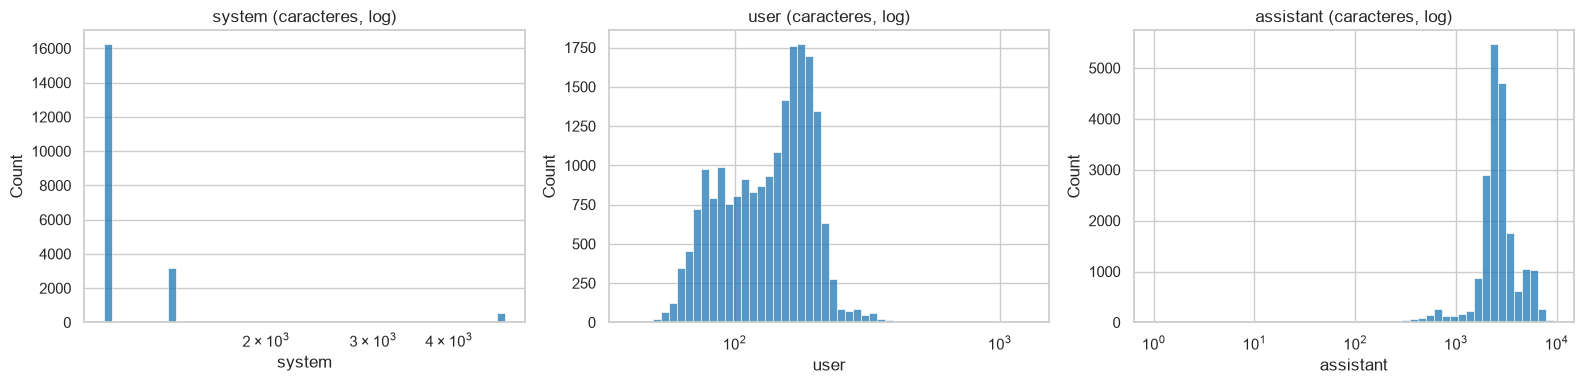

In [4]:
L = text_lengths(df, ["system", "user", "assistant"])
display(L.describe().round(1))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, L.columns):
    sns.histplot(L[c].clip(lower=1), bins=50, log_scale=True, ax=ax); ax.set_title(f"{c} (caracteres, log)")
plt.tight_layout(); save_fig(fig, ctx, "largo_textos"); plt.show()

## 4. Prompts de sistema, duplicados y plantillas

In [5]:
print("System prompts distintos:", df["system"].nunique())
display(df["system"].str[:150].value_counts().head(10).to_frame("n"))

display(duplicates_report(df, {"user": ["user"], "assistant": ["assistant"], "user + assistant": ["user", "assistant"]}))

# Señal de plantillas: primeras 4 palabras más comunes del mensaje del usuario
first_words = df["user"].fillna("").str.split().str[:4].str.join(" ")
display(first_words.value_counts().head(15).to_frame("n"))

System prompts distintos: 4


,n
system,
"You are a highly specialized AI assistant for advanced cyber-defense whose mission is to deliver accurate, in-depth, actionable guidance on informatio",15299
"You are a highly specialized AI assistant for advanced cyber-defense whose mission is to deliver accurate, in-depth, actionable guidance on informati",4134
"You are an advanced AI assistant specialized in cybersecurity causal reasoning and threat analysis. Your expertise encompasses offensive security, def",567


,duplicados,%
criterio,,
user,396,1.98
assistant,16,0.08
user + assistant,0,0.00


,n
user,
How would you design,549
How would you architect,425
In which scenarios would,202
What are the methods,175
What are the techniques,167
Under what circumstances could,164
In which situations would,152
How would you integrate,144
Under what circumstances would,141


In [6]:
# ¿Cuántas respuestas son negativas/rechazos? (patrón aproximado)
REFUSAL = r"(?i)\b(?:I can(?:no|')t|I won't|I'm sorry|I am sorry|I must decline|I can't assist)\b"
ref = df["assistant"].fillna("").str.contains(REFUSAL)
print(f"Respuestas con patrón de rechazo: {ref.sum():,} ({ref.mean():.1%})")

Respuestas con patrón de rechazo: 209 (1.0%)


## Ejemplos

In [7]:
show_examples(df, n=2, cols=["user", "assistant"], max_chars=800)

fila 19134
--- user ---
How can formal verification prove JWT implementation security? Implement mathematical proofs for cryptographic operations and state machines.
--- assistant ---
Formal verification in JSON Web Token (JWT) implementations provides mathematically rigorous proof of cryptographic operation correctness and state machine integrity, addressing critical vulnerabilities through symbolic reasoning and model checking.\n\n**Cryptographic Operation Verification**\n\nFormal verification employs mathematical models to prove cryptographic primitives' correctness. For JWT HMAC-SHA256 operations, formal methods verify that the hash function's properties (collision resistance, preimage resistance) hold under all possible inputs. The verification process constructs symbolic representations of cryptographic algorithms using theorem provers like Coq or Isabelle/HOL. These systems encode algorithm specifications as mathematical propositions and prove their validity thro […]
fila 4981
-